<a href="https://colab.research.google.com/github/noyeem99/privacy-preserving-deep-learning/blob/main/09-adaptive_noise_scheduling_dp_sgd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Initializing Adaptive Noise Multiplier Scheduling System...

=== STARTING TRAINING WITH ADAPTIVE NOISE MULTIPLIER SCHEDULING ===
[EPOCH 01/20] Loss: 0.7255 | Scheduled Noise Multiplier: 2.0000
[EPOCH 02/20] Loss: 0.6983 | Scheduled Noise Multiplier: 1.9048
[EPOCH 03/20] Loss: 0.6958 | Scheduled Noise Multiplier: 1.8182
[EPOCH 04/20] Loss: 0.6946 | Scheduled Noise Multiplier: 1.7391
[EPOCH 05/20] Loss: 0.6943 | Scheduled Noise Multiplier: 1.6667
[EPOCH 06/20] Loss: 0.6912 | Scheduled Noise Multiplier: 1.6000
[EPOCH 07/20] Loss: 0.6940 | Scheduled Noise Multiplier: 1.5385
[EPOCH 08/20] Loss: 0.6950 | Scheduled Noise Multiplier: 1.4815
[EPOCH 09/20] Loss: 0.6937 | Scheduled Noise Multiplier: 1.4286
[EPOCH 10/20] Loss: 0.6944 | Scheduled Noise Multiplier: 1.3793
[EPOCH 11/20] Loss: 0.6927 | Scheduled Noise Multiplier: 1.3333
[EPOCH 12/20] Loss: 0.6943 | Scheduled Noise Multiplier: 1.2903
[EPOCH 13/20] Loss: 0.6951 | Scheduled Noise Multiplier: 1.2500
[EPOCH 14/20] Loss: 0.6934 | Sch

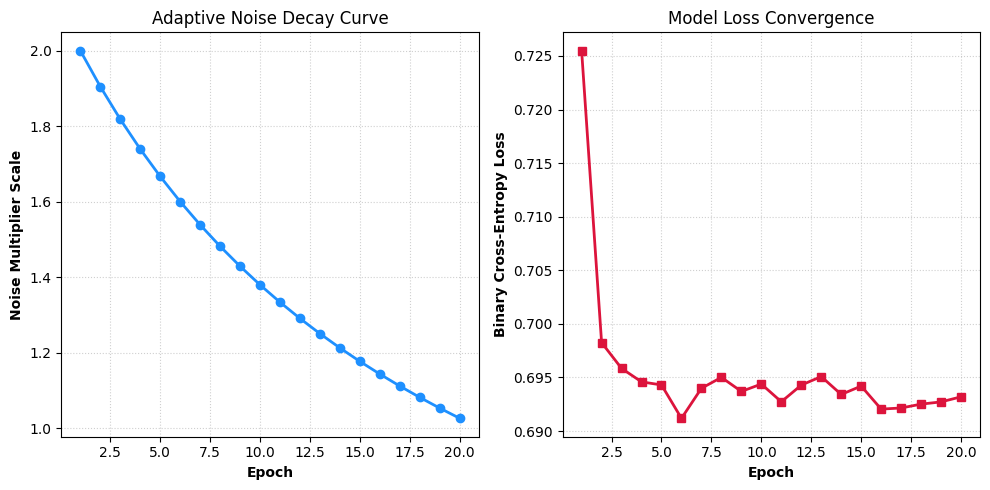

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Set environment seeds for absolute reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("[INFO] Initializing Adaptive Noise Multiplier Scheduling System...")

# 2. Generate Synthetic Dataset
X = np.random.normal(loc=0.0, scale=1.0, size=(1000, 10))
y = np.random.randint(0, 2, size=(1000, 1))

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# 3. Model Definition (Simple Linear Architecture)
class TargetClassifier(nn.Module):
    def __init__(self):
        super(TargetClassifier, self).__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return torch.sigmoid(self.fc(x))

model = TargetClassifier()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 4. Define Adaptive Noise Scheduling parameters
epochs = 20
batch_size = 32
max_grad_norm = 1.0

# Base configuration for dynamic noise decay
initial_noise_multiplier = 2.0
decay_rate = 0.05

noise_history = []
loss_history = []

print("\n=== STARTING TRAINING WITH ADAPTIVE NOISE MULTIPLIER SCHEDULING ===")

# 5. Training Loop with Row-level DP-SGD Simulation & Dynamic Noise Decay
for epoch in range(epochs):
    # Dynamic Decay Logic: Noise scale reduces over time to recover model utility
    current_noise_multiplier = initial_noise_multiplier / (1.0 + decay_rate * epoch)
    noise_history.append(current_noise_multiplier)

    epoch_losses = []

    # Shuffle indices per epoch
    permutation = torch.randperm(X_tensor.size(0))

    for i in range(0, X_tensor.size(0), batch_size):
        optimizer.zero_grad()

        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_tensor[indices], y_tensor[indices]

        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()

        # Row-Level DP-SGD Mechanism: Clip per-sample gradients manually and inject adaptive noise
        with torch.no_grad():
            for param in model.parameters():
                if param.grad is not None:
                    # Clip gradients to restrict sensitivity
                    param.grad.clamp_(-max_grad_norm, max_grad_norm)

                    # Calibrate Gaussian noise scaling with the scheduled multiplier
                    noise = torch.randn_like(param.grad) * (max_grad_norm * current_noise_multiplier / batch_size)
                    param.grad.add_(noise)

        optimizer.step()
        epoch_losses.append(loss.item())

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f"[EPOCH {epoch+1:02d}/{epochs}] Loss: {avg_loss:.4f} | Scheduled Noise Multiplier: {current_noise_multiplier:.4f}")

print("\n[SUCCESS] Custom Adaptive Noise Optimization Loop Completed.")

# 6. Generate Research-Grade Performance Visualization Plots
plt.figure(figsize=(10, 5))

# Plot 1: Scheduled Adaptive Noise Multiplier Decay
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), noise_history, color='dodgerblue', marker='o', lw=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Noise Multiplier Scale', fontweight='bold')
plt.title('Adaptive Noise Decay Curve')
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Empirical Loss Convergence
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), loss_history, color='crimson', marker='s', lw=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Binary Cross-Entropy Loss', fontweight='bold')
plt.title('Model Loss Convergence')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

